# Exploring AAPL Stock Data with Pandas and Matplotlib

In this assignment, you will use `AAPL.csv` to practice basic data inspection, summary statistics, and plotting with Pandas and Matplotlib.

The dataset contains daily Apple stock price data with the columns `date`, `adj_close`, `close`, `high`, `low`, `open`, `volume`, and `symbol`.

For each exercise, write your code between the `# <START>` and `# <END>` comments. 


In [3]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')


## Exercise 1: Load and Inspect the Dataset

Read `AAPL.csv` into a DataFrame named `df`. Then display:

- The first 10 rows
- The shape of the dataset
- The column names
- The data types of each column


In [4]:
# <START>
# Read AAPL.csv into df
df = pd.read_csv('AAPL.csv')

# Display the first 10 rows
print(df.head(10))

# Display the shape, columns, and data types
print(df.shape, df.columns, df.dtypes)
# <END>


         date  adj_close      close       high        low       open  \
0  2015-01-02  24.192606  27.332500  27.860001  26.837500  27.847500   
1  2015-01-05  23.511055  26.562500  27.162500  26.352501  27.072500   
2  2015-01-06  23.513268  26.565001  26.857500  26.157499  26.635000   
3  2015-01-07  23.842981  26.937500  27.049999  26.674999  26.799999   
4  2015-01-08  24.759077  27.972500  28.037500  27.174999  27.307501   
5  2015-01-09  24.785631  28.002501  28.312500  27.552500  28.167500   
6  2015-01-12  24.174902  27.312500  28.157499  27.200001  28.150000   
7  2015-01-13  24.389544  27.555000  28.200001  27.227501  27.857500   
8  2015-01-14  24.296606  27.450001  27.622499  27.125000  27.260000   
9  2015-01-15  23.637186  26.705000  27.514999  26.665001  27.500000   

      volume symbol  
0  212818400   AAPL  
1  257142000   AAPL  
2  263188400   AAPL  
3  160423600   AAPL  
4  237458000   AAPL  
5  214798000   AAPL  
6  198603200   AAPL  
7  268367600   AAPL  
8  195826

## Exercise 2: Convert and Sort Dates

The `date` column is currently read as text. Convert it to a datetime column, sort the rows by date, and reset the index.

After sorting, display the earliest date and latest date in the dataset.


In [5]:
# <START>
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date and reset the index
df.sort_values('date')
df.reset_index
# Display the first and last dates
print(df.head(1))
print(df.tail(1))
# <END>


        date  adj_close    close       high      low     open     volume  \
0 2015-01-02  24.192606  27.3325  27.860001  26.8375  27.8475  212818400   

  symbol  
0   AAPL  
           date   adj_close       close        high         low        open  \
2857 2026-05-14  298.209991  298.209991  300.350006  295.380005  299.820007   

        volume symbol  
2857  33673067   AAPL  


## Exercise 3: Summary Statistics

Find the mean, standard deviation, highest value, and lowest value for these numerical columns:

- `open`
- `high`
- `low`
- `close`
- `adj_close`
- `volume`

Store the result in a variable named `summary_stats` and display it.


In [10]:
numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']

# <START>
# Calculate mean, standard deviation, minimum, and maximum
summary_stats = df[numeric_cols].agg(['mean','std','min','max'])
# Display summary_stats
print(summary_stats)
# <END>


            open        high         low       close   adj_close        volume
mean  113.560275  114.790064  112.422560  113.659821  111.213828  1.093330e+08
std    77.639929   78.469748   76.889401   77.717700   78.157844  6.794444e+07
min    22.500000   22.917500   22.367500   22.584999   20.565870  1.791060e+07
max   299.820007  300.920013  295.380005  298.869995  298.869995  6.488252e+08


## Exercise 4: Highest and Lowest Adjusted Close

Find the row where Apple had the highest `adj_close` price and the row where it had the lowest `adj_close` price.

Display the `date`, `adj_close`, and `volume` for both rows.


In [28]:
# <START>
# Find the index of the highest and lowest adjusted close values
idx_max = df['adj_close'].idxmax()
idx_min = df['adj_close'].idxmin()

# Select date, adj_close, and volume for both rows

print('Highest adjusted close:', idx_max)
print(df.loc[[idx_max],['date','adj_close','volume']])

print('Lowest adjusted close:', idx_min)
print(df.loc[[idx_min],['date','adj_close','volume']])

# <END>


Highest adjusted close: 2856
           date   adj_close    volume
2856 2026-05-13  298.869995  52684300
Lowest adjusted close: 342
          date  adj_close     volume
342 2016-05-12   20.56587  305258800


## Exercise 5: Plot Date vs Adjusted Close

Create a line plot showing how `adj_close` changes over time.

Your plot should include:

- Figure size `(12, 5)`
- A blue line
- Title: `AAPL Adjusted Close Price Over Time`
- X-axis label: `Date`
- Y-axis label: `Adjusted Close Price`


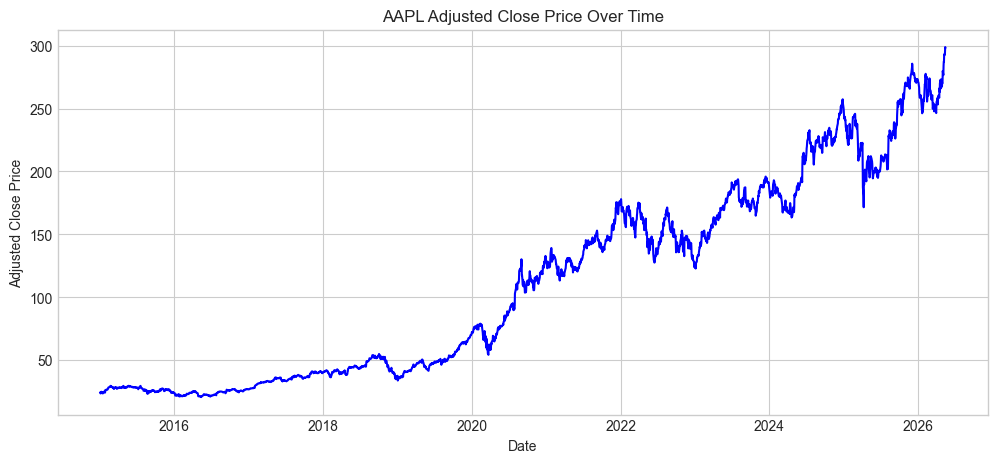

In [56]:
# <START>
plt.figure(figsize=(12,5))
plt.plot(df['date'],df['adj_close'],color='blue')
plt.title("AAPL Adjusted Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.show()
# <END>


## Exercise 6: Plot Trading Volume Over Time

Create a line plot for `volume` over time.

Your plot should include:

- Figure size `(12, 5)`
- A purple line
- Title: `AAPL Trading Volume Over Time`
- X-axis label: `Date`
- Y-axis label: `Volume`


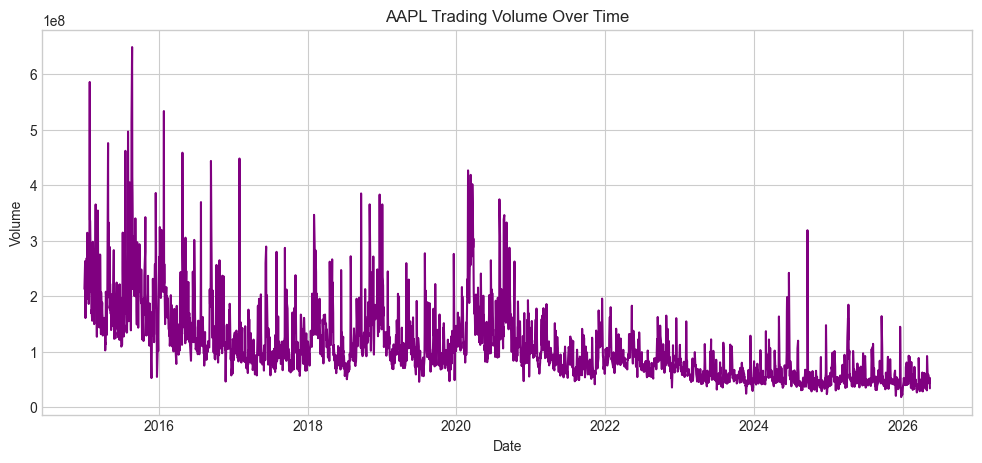

In [46]:
# <START>
plt.figure(figsize=(12,5))
plt.title("AAPL Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.plot(df['date'],df['volume'],color='purple')

# <END>


## Exercise 7: Top 10 Highest Volume Days

Find the 10 days with the highest trading volume and store them in `top_volume_days`.

Then create a bar chart with:

- `date` on the X-axis
- `volume` on the Y-axis
- Title: `Top 10 AAPL Trading Volume Days`
- Rotated X-axis labels so the dates are readable


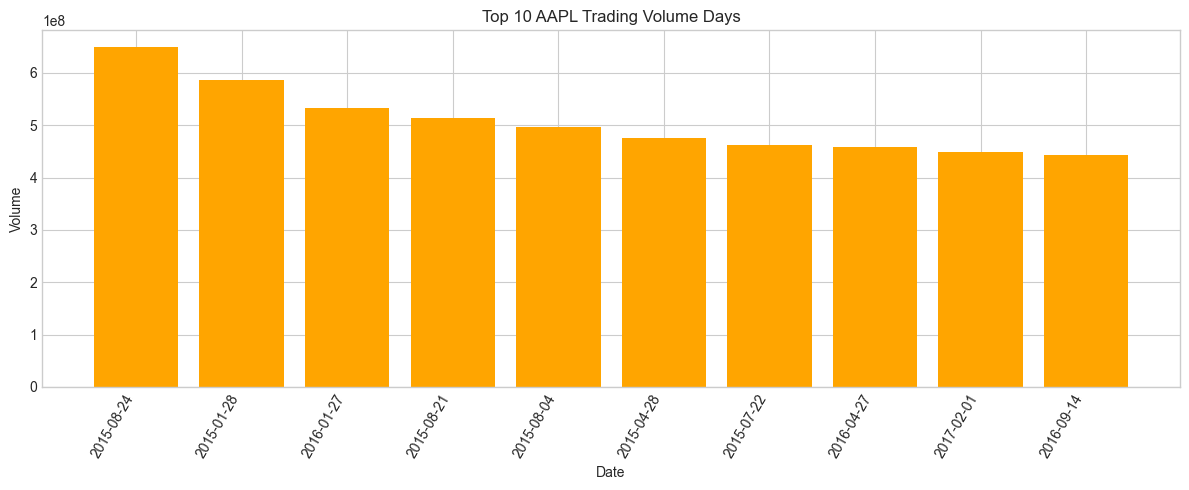

In [58]:
# <START>
# Find the 10 highest volume days
sorted_df_volume = df.sort_values('volume', ascending=False)
top_volume_days = sorted_df_volume.head(10)
# Plot the result
plt.figure(figsize=(12, 5))
plt.bar(top_volume_days['date'].dt.strftime('%Y-%m-%d'), top_volume_days['volume'], color='orange')
plt.title('Top 10 AAPL Trading Volume Days')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()
# <END>


## Exercise 8: Moving Average Plot

Create two new columns:

- `ma_20`: 20-day moving average of `adj_close`
- `ma_50`: 50-day moving average of `adj_close`

Then plot `adj_close`, `ma_20`, and `ma_50` on the same graph.


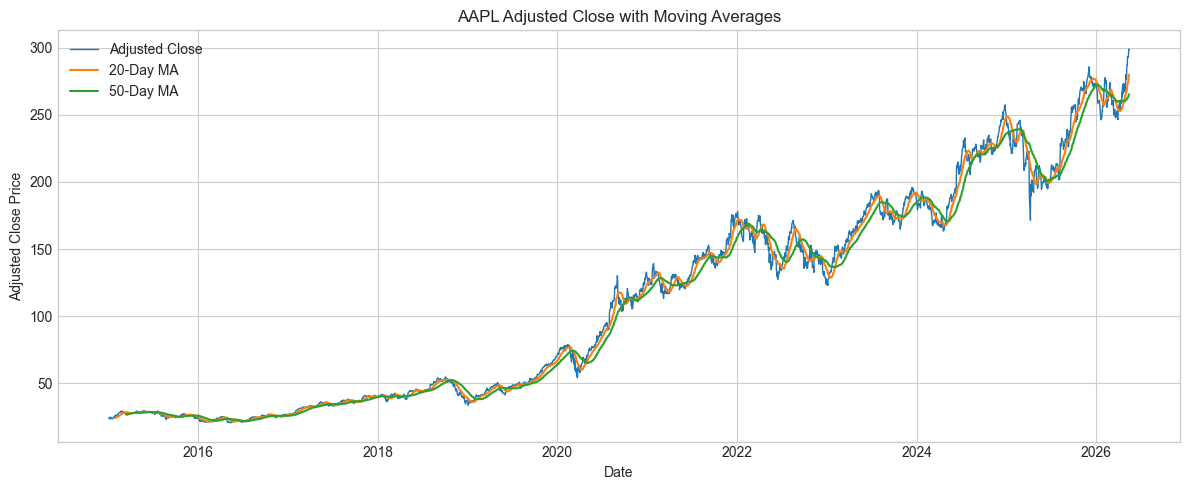

In [76]:
# <START>
# Calculate moving averages
df['ma_20'] = df['adj_close'].rolling(window=20).mean()
df['ma_50'] = df['adj_close'].rolling(window=50).mean()
# Plot adjusted close and moving averages
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['adj_close'], label='Adjusted Close', linewidth=1)
plt.plot(df['date'], df['ma_20'], label='20-Day MA', linewidth=1.5)
plt.plot(df['date'], df['ma_50'], label='50-Day MA', linewidth=1.5)
plt.title('AAPL Adjusted Close with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()
# <END>


## Exercise 9: Relationship Between Daily Range and Volume

Create a new column named `daily_range` using:

`daily_range = high - low`

Then make a scatter plot with `daily_range` on the X-axis and `volume` on the Y-axis.


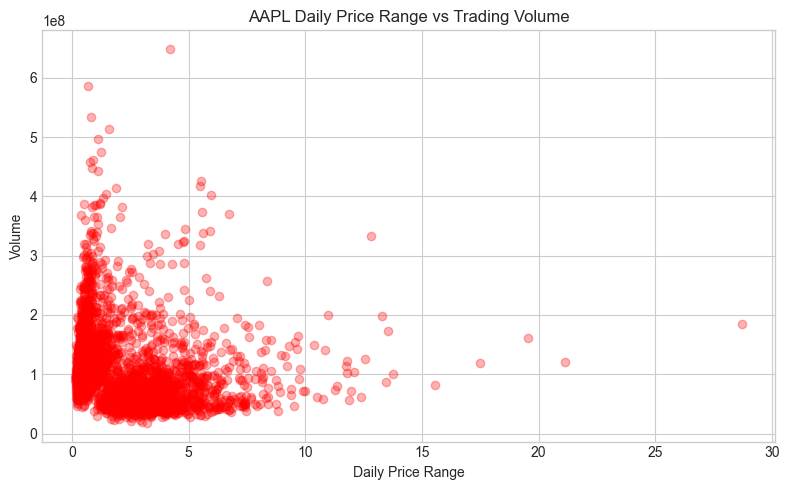

In [83]:
# <START>
# Calculate daily range
df['daily_range'] = df['high']-df['low']
# Create scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['daily_range'], df['volume'], alpha=0.3, color='red')
plt.title('AAPL Daily Price Range vs Trading Volume')
plt.xlabel('Daily Price Range')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()
# <END>


## Bonus Exercise: Monthly Average Adjusted Close

Group the data by month and calculate the average `adj_close` for each month. Plot the monthly averages as a line plot.

Hint: Use `df.set_index('date').resample('ME')`.


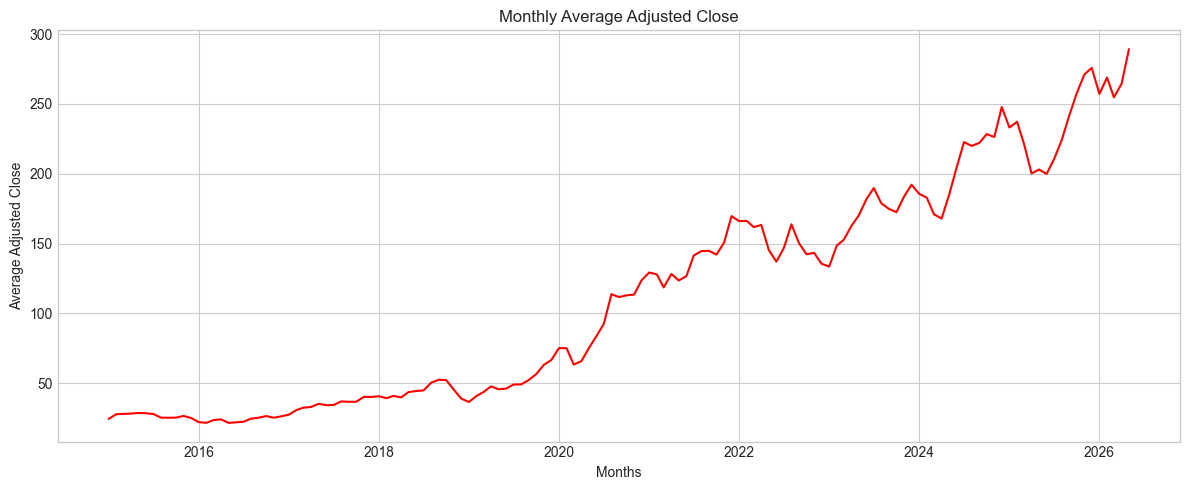

In [ ]:
# <START>
# Calculate monthly average adjusted close

# df['month'] = df['date'].dt.strftime('%b')

# months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
# adj_close_month = []

# # print(df[df['month']=='May'])

# for mon in months:
#     data = df[df['month']==mon]
#     mean = data['adj_close'].agg('mean')
#     adj_close_month.append(mean)

monthly = df.set_index('date').resample('ME')['adj_close'].mean()


# Plot monthly average adjusted close
plt.figure(figsize=(12,5))
plt.plot(monthly.index,monthly.values,color='r')
plt.title("Monthly Average Adjusted Close")
plt.xlabel("Months")
plt.ylabel("Average Adjusted Close")
plt.tight_layout()
plt.show()
# <END>
